In [61]:
from cirq_sic import *

def calculate_magic(d, alpha, P):
    return (1/(1-alpha))*np.log(np.sum(P[:,0]**alpha)) - np.log(d)

def calculate_LTP_deformation(d, P):
    return np.linalg.norm(np.linalg.pinv(P) - np.eye(d**2))

alpha = 2
ds = np.arange(2, 9)
T = np.linspace(0, 1, 75)

data = {}
for d in ds:
  psi_stab = np.eye(d)[0]
  psi_sic = load_sic_fiducial(d)
  interpolation = geodesic_interpolator(psi_stab, psi_sic)

  max_magic = (1/(1-alpha))*np.log((1+(d-1)*float(d+1)**(1-alpha))/d)
  sic_deformation = np.linalg.norm(np.eye(d**2) - np.linalg.inv(SIC_P(d)))

  magics = []
  deformations = []
  for t in T:
    psi = interpolation(t)
    E = wh_povm(psi)
    P = np.array([[(a@b).trace()/b.trace() for b in E] for a in E]).real
    magic = calculate_magic(d, alpha, P)
    LTP_deformation = calculate_LTP_deformation(d, P)
    magics.append(magic)
    deformations.append(LTP_deformation)
    
  data[d] = {"magics": magics, "deformations": deformations}

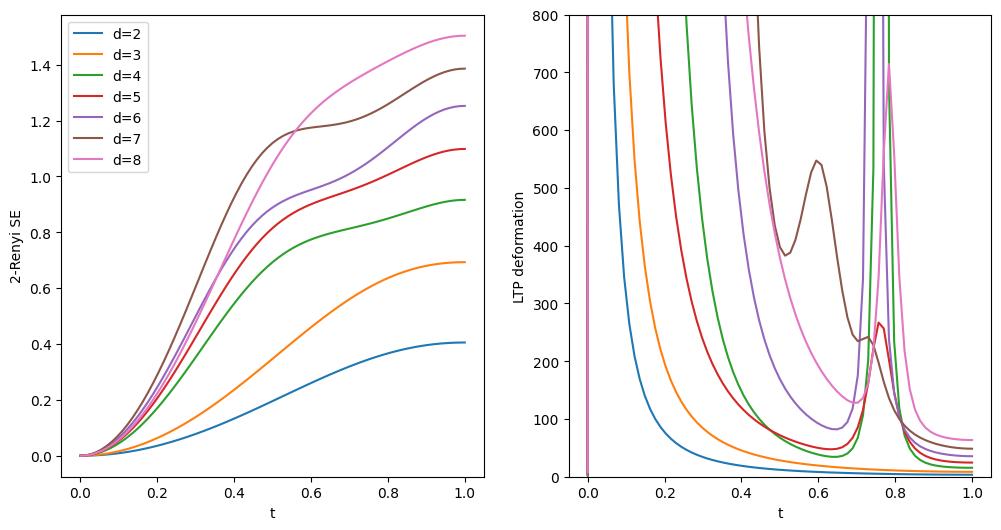

In [65]:
fig, axes, = plt.subplots(1, 2, figsize=(12,6))
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

for i, d in enumerate(ds):
    axes[0].plot(T, data[d]["magics"], label="d=%d" % d, color=colors[i])

axes[0].set_xlabel("t")
axes[0].set_ylabel(r"%d-Renyi SE" % alpha)

for i, d in enumerate(ds):
    axes[1].plot(T, data[d]["deformations"], label="d=%d" % d, color=colors[i])

axes[1].set_ylim(0, 800)
axes[1].set_xlabel("t")
axes[1].set_ylabel(r"LTP deformation")

axes[0].legend()
fig.savefig("many_d.pdf")